In [105]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Apr 25 2025

@author: Yaning
Data from https://github.com/sjgershm/rational-discounting/tree/master/data
(find out where the data is originally from)
"""

# get the real percentage of the participants
# %run /home/yaning/Documents/Discounting/data_analysis/percentage_comparison.ipynb
# %run /home/yaning/Documents/Discounting/data_analysis/data_analysis(matlab_dataset).ipynb


import torch
import pyro.distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats 
import pickle

In [106]:
with open('/home/yaning/Documents/Discounting/results/buhui_separate_sigma_distri.pkl', 'rb') as f:
    pos_dict = pickle.load(f)
    
with open('/home/yaning/Documents/Discounting/results/array_buhui.pkl', 'rb') as f:
    data = pickle.load(f)

In [107]:
pos_dict['m_locs'].shape

(221, 5)

In [108]:
pos_params = pos_dict['m_locs']

In [109]:
pos_params.shape

(221, 5)

In [110]:
# # transfer the inferred parameters to cpu
# pos_mean_u = pos_params[:,0]
# pos_sigma_u = np.exp(pos_params[:,1])
# pos_sigma_es = np.exp(pos_params[:,2])
# # pos_sigma_ss = np.exp(pos_params[:,3])
# pos_beta = np.exp(pos_params[:,3])

# ---exponential and constant mix delay-----
# pos_mean_u = pos_params[:,0]
# pos_sigma_u = np.exp(pos_params[:,1])
# pos_sigma_es = np.exp(pos_params[:,2])
# pos_a = np.exp(pos_params[:,3])
# pos_b =np.exp(pos_params[:,4])
# pos_c =np.exp(pos_params[:,5])
# pos_beta = np.exp(pos_params[:,6])

# # ---no sigma_es (=1) and c-----
# pos_mean_u = pos_params[:,0]
# pos_sigma_u = np.exp(pos_params[:,1])
# pos_sigma_es = np.exp(pos_params[:,2])
# pos_a = np.exp(pos_params[:,3])
# pos_b =np.exp(pos_params[:,4])
# pos_beta = np.exp(pos_params[:,5])

# ---no sigma_es or c or mean_u-----
# pos_mean_u = np.exp(pos_params[:,0])
# pos_sigma_u = np.exp(pos_params[:,0])
# pos_a = np.exp(pos_params[:,2])
# pos_b =np.exp(pos_params[:,1])
# pos_c =pos_params[:,4]
# pos_beta = np.exp(pos_params[:,2])


# -----------sigma_rate model---------------
# # sigma_rate model
# pos_mean_u = pos_params[:,0]
# pos_sigma_rate = np.exp(pos_params[:,1])
# pos_beta = np.exp(pos_params[:,2])

# # # ------------constant sigma rate------------
pos_sigma_prior = np.exp(pos_params[:,0])
# pos_sigma_rate = np.exp(pos_params[:,0])
pos_a = np.exp(pos_params[:,1])
pos_b = np.exp(pos_params[:,2])
pos_c = np.exp(pos_params[:,3])
pos_beta = np.exp(pos_params[:,4])

# pos_dis_rate = np.exp(pos_params[:,0])
# pos_beta = np.exp(pos_params[:,1])
# pos_a_sigma = np.exp(pos_params[:,0])
# pos_b_sigma = np.exp(pos_params[:,1])
# pos_a = pos_params[:,2]
# pos_b = pos_params[:,3]
# pos_beta = pos_params[:,4]


In [47]:
data.shape

(221, 240, 5)

In [91]:
trial_num = data.shape[1]

In [111]:
sigma_prior = np.tile(pos_sigma_prior[:, np.newaxis], (1, trial_num))
a = np.tile(pos_a[:, np.newaxis], (1, trial_num))
b = np.tile(pos_b[:, np.newaxis], (1, trial_num))
c = np.tile(pos_c[:, np.newaxis], (1, trial_num))
# dis_rate = np.tile(pos_dis_rate[:, np.newaxis], (1, trial_num))
beta = np.tile(pos_beta[:, np.newaxis], (1, trial_num))
# a_sigma = np.tile(pos_a_sigma[:, np.newaxis], (1, trial_num))
# b_sigma = np.tile(pos_b_sigma[:, np.newaxis], (1, trial_num))



# # add ss model
# sigma_ss = np.tile(pos_sigma_ss[:, np.newaxis], (1, trial_num))


# # sigma_rate model
# mean_u = np.tile(pos_mean_u[:, np.newaxis], (1, trial_num))
# sigma_rate = np.tile(pos_sigma_rate[:, np.newaxis], (1, trial_num))
# beta = np.tile(pos_beta[:, np.newaxis], (1, trial_num))

In [124]:
sigma_es = c/(1+b*np.exp(-a*data[:,:,2]))
e_mean = (data[:,:,3])*sigma_prior**2/(sigma_es**2 + sigma_prior**2)

e_sigma = (sigma_es**2*sigma_prior**2)/(sigma_prior**2 + sigma_es**2)

        
# e_mean = (mean_u*delay**2 + real_data[:,:,3]*sigma_rate**2)/(delay**2 + sigma_rate**2)
# e_sigma = ((sigma_rate**2*delay**2)/(sigma_rate**2 + delay**2))**0.5

# e_mean = (real_data[:,:,3]*sigma_u**2)/(delay**2 + sigma_u**2)
# e_sigma = ((sigma_u**2*delay**2)/(sigma_u**2 + delay**2))**0.5

# e_mean = (mean_u*delay + 
#  real_data[:,:,3]*sigma_u**2)/(delay + sigma_u**2)
# e_sigma = ((sigma_u**2*delay)/(sigma_u**2 + delay))**0.5

# e_mean = (data[:,:,3])/(1 + dis_rate*data[:,:,2])

# sigma_combine = sigma_rate/(1+b*np.exp(-a*data[:,:,2]))
# e_mean = (data[:,:,3])/(sigma_combine**2 + 1)

e_mean = torch.tensor(e_mean)
e_sigma = torch.tensor(e_sigma)
real_data = torch.tensor(data)
beta = torch.tensor(beta)

e_dist  = dist.Normal(e_mean, e_sigma)

pos = 1 - e_dist.cdf(torch.tensor(1.))


softmax_args = torch.stack([beta*pos, beta*(1-pos)])
# softmax_args = torch.stack([beta*e_mean, beta*torch.tensor(1.)])
p = torch.softmax(softmax_args, dim = 0)[0]

# -----------------------------sigma_rate model--------------------------------

# # sigma_rate model
# inferred_estimation = (mean_u*real_data[:,:,2]*sigma_rate**2 + 
#  real_data[:,:,3])/(real_data[:,:,2]*sigma_rate**2 + 1)

# ------------------------------------------------------------------------------

# sigma_u = torch.tensor(6.)
# inferred_estimation = (torch.tensor(0.5)*real_data[:,:,2]*sigma_es**2 + 
#  real_data[:,:,3]*sigma_u**2)/(real_data[:,:,2]*sigma_es**2 + sigma_u**2)

# # ------------------------Normal Model--------------------------------------
# # change everything to tensor
# real_data = torch.tensor(real_data)
# inferred_estimation = torch.tensor(inferred_estimation)
# beta = torch.tensor(beta)


# # create softmax and the bernoulli distribution
# softmax_args = torch.stack([beta*inferred_estimation, beta*real_data[:,:,1]])
# p = torch.softmax(softmax_args, dim = 0)[0]
inferred_response_distr = dist.Bernoulli(probs=p)

/tmp/ipykernel_1179289/1524669367.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  beta = torch.tensor(beta)


In [125]:
# get one possible predict actions
inferred_response = inferred_response_distr.sample()

In [19]:
# reshape to with contexts for plotting
reshaped_inferred_response = inferred_response.reshape(2,30,trial_num)

Check the graph fitting.

In [20]:
# calculate the predicted LL choosing percentage
inferred_percentages = []
for i in reshaped_inferred_response:
    temp = []
    for j in i:
        temp.append(len(list(filter(lambda x: (x == 1), j))
                ) / len(j))
    inferred_percentages.append(temp)

In [21]:
inferred_percentages = np.array(inferred_percentages)

In [22]:
# separate to pairs so can make line plot
infer_line = []
for i,j in zip(inferred_percentages[0], inferred_percentages[1]):
    infer_line.append([i,j])

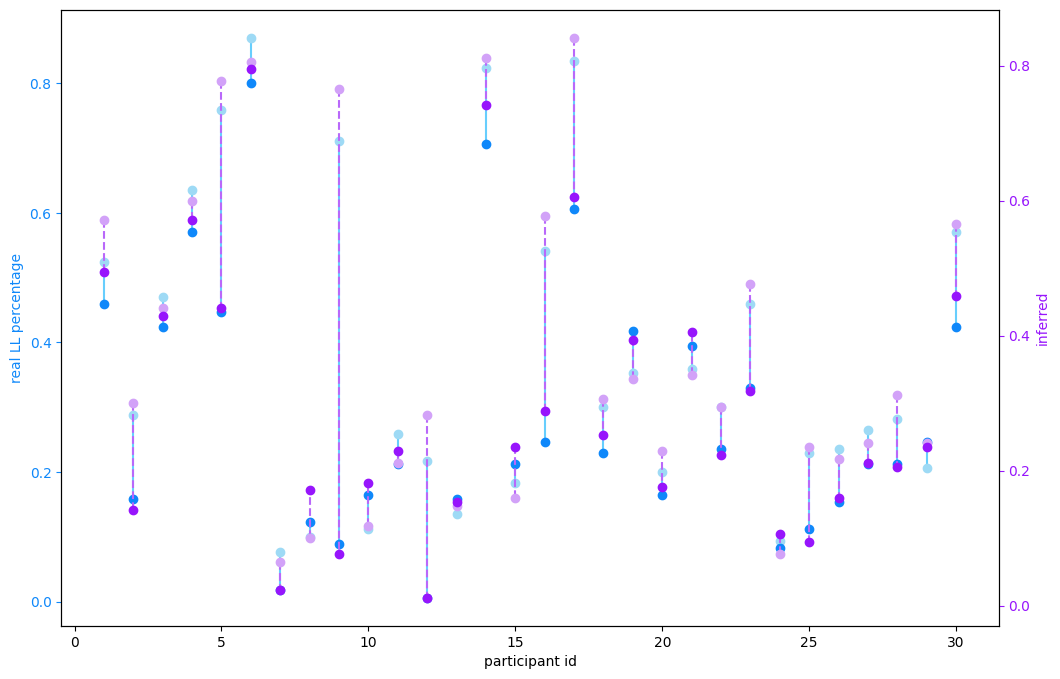

In [23]:
# plot real percentage and infered parameters together
fig, ax = plt.subplots(figsize=(15,8))

# Twin the x-axis twice to make independent y-axes.
axes = [ax, ax.twinx()]

# Make some space on the right side for the extra y-axis.
fig.subplots_adjust(right=0.75)

# lighter dots are cafe and darker dots are gamble
# plot the real percentage (blue)
for i in range(len(line_data)):
    x = [i+1, i+1]
    y = [line_data[i][0], line_data[i][1]]
    axes[0].plot(x, y, color="#67cefd", ls = '-')
    axes[0].plot(i+1, y[0], color ="#9edaf5", marker = "o")
    axes[0].plot(i+1, y[1], color = "#0f88fa", marker = "o")
axes[0].set_ylabel("real LL percentage", color = "#0f88fa")
axes[0].tick_params(axis='y', colors = "#0f88fa")
axes[0].set_xlabel("participant id")

# inferred percentages (purple)
for i in range(len(infer_line)):
    x = [i+1, i+1]
    y_inferred = [infer_line[i][0], infer_line[i][1]]
    axes[1].plot(x, y_inferred, color="#b968fa", ls = "--")
    axes[1].plot(i+1, y_inferred[0], color = "#d2a2f8", marker = "o")
    axes[1].plot(i+1, y_inferred[1], color = "#9715fc", marker = "o")
axes[1].set_ylabel("inferred", color = "#9715fc")
axes[1].tick_params(axis='y', colors = "#9715fc")

# big_gap = [1, 4, 8, 11, 13, 15, 16, 22, 24, 29]
# # inferred percentages (purple)
# for i in range(len(big_gap)):
#     x = [big_gap[i]+1, big_gap[i]+1]
#     y_inferred = [infer_line[i][0], infer_line[i][1]]
#     axes[1].plot(x, y_inferred, color="#b968fa", ls = "--")
#     axes[1].plot(big_gap[i]+1, y_inferred[0], color = "#d2a2f8", marker = "o")
#     axes[1].plot(big_gap[i]+1, y_inferred[1], color = "#9715fc", marker = "o")
# axes[1].set_ylabel("inferred", color = "#9715fc")
# axes[1].tick_params(axis='y', colors = "#9715fc")


plt.show()

Check the correctly predicted percentage.

In [126]:
# create only one dimension array
# get how many are correctly predicted
real_response = real_data[:,:,4].view(-1)
num = 0
for i in range(len(real_response)):
    if inferred_response.view(-1)[i] == real_response[i]:
        num = num + 1

In [127]:
num/len(real_response)

0.9436651583710407

Plot the parameters with the real LL choosing percentage.

In [479]:
# plot_pos_param = pos_sigma_es.reshape(2,30) - pos_sigma_u.reshape(2,30)
plot_param = pos_sigma_es.reshape(2,30)

In [481]:
np.corrcoef(pos_sigma_u, pos_sigma_es)

array([[1.        , 0.07775218],
       [0.07775218, 1.        ]])

In [482]:
# separate to pairs so can make line plot
param_line = []
for i,j in zip(plot_param[0], plot_param[1]):
    param_line.append([i,j])

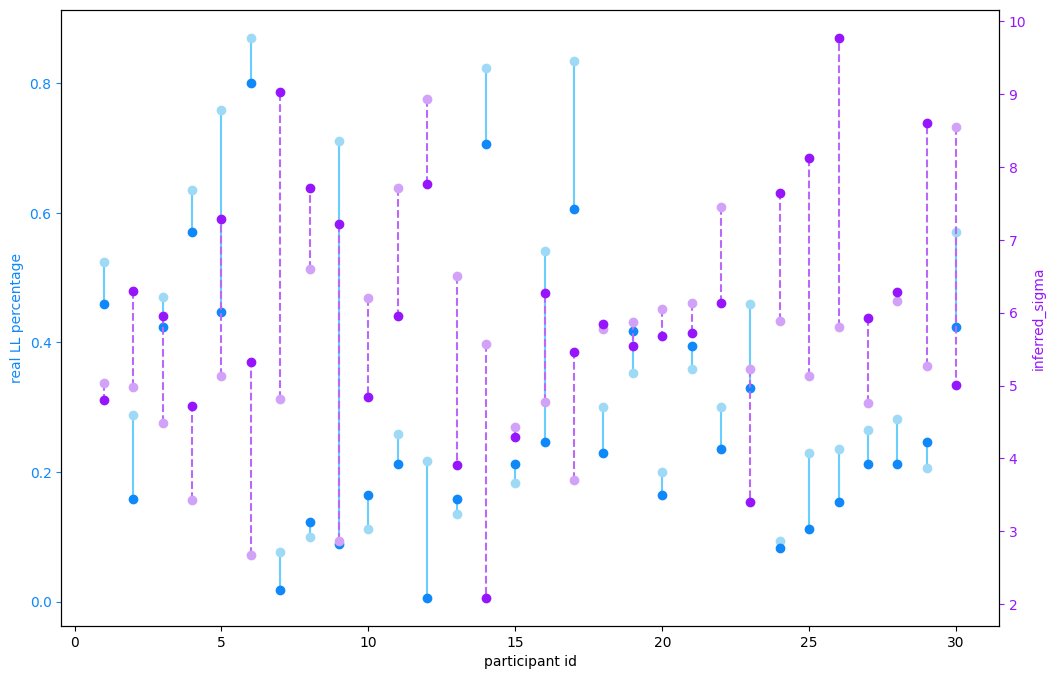

In [483]:
# plot real percentage and infered parameters together
fig, ax = plt.subplots(figsize=(15,8))

# Twin the x-axis twice to make independent y-axes.
axes = [ax, ax.twinx()]

# Make some space on the right side for the extra y-axis.
fig.subplots_adjust(right=0.75)

# lighter dots are cafe and darker dots are gamble
# plot the real percentage (blue)
for i in range(len(line_data)):
    x = [i+1, i+1]
    y = [line_data[i][0], line_data[i][1]]
    axes[0].plot(x, y, color="#67cefd", ls = '-')
    axes[0].plot(i+1, y[0], color ="#9edaf5", marker = "o")
    axes[0].plot(i+1, y[1], color = "#0f88fa", marker = "o")
axes[0].set_ylabel("real LL percentage", color = "#0f88fa")
axes[0].tick_params(axis='y', colors = "#0f88fa")
axes[0].set_xlabel("participant id")

# inferred percentages (purple)
for i in range(len(param_line)):
    x = [i+1, i+1]
    y_inferred = [param_line[i][0], param_line[i][1]]
    axes[1].plot(x, y_inferred, color="#b968fa", ls = "--")
    axes[1].plot(i+1, y_inferred[0], color = "#d2a2f8", marker = "o")
    axes[1].plot(i+1, y_inferred[1], color = "#9715fc", marker = "o")
axes[1].set_ylabel("inferred_sigma", color = "#9715fc")
axes[1].tick_params(axis='y', colors = "#9715fc")



plt.show()